In [1]:
%load_ext autoreload
%autoreload 2

import warnings
from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import torch
import uproot
from particle import Particle
from torch_geometric.data import Data
from tqdm import tqdm

from analysis.utils.colors import TangoColors
from analysis.utils.event_display import show_hist_plots, show_scatter_plots
from analysis.utils.geometry import Geometry, get_geometry, get_rebinned_geometry
from analysis.utils.plot_utils import add_legend, setup
from analysis.utils.preprocessing_utils import (
    create_parquet_from_root,
    get_good_event_ids,
    get_rebinned_df,
)
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import mrad, um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_figures_path,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
    get_torch_path,
)

warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)


/Users/tboeckh/Library/Caches/pypoetry/virtualenvs/analysis-mEzhAUyO-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
setup()

In [3]:
def get_data(
    run: int, chunks=int | list[int]
) -> list[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    hits_dfs = []
    truth_dfs = []
    faser_dfs = []
    tau_dfs = []
    if isinstance(chunks, int):
        chunks = [chunks]
    for chunk in chunks:
        path = get_parquet_path() / f"{run:05d}"
        hits_path = path / f"{run:05d}_{chunk:03d}_hits.parq"
        truth_path = path / f"{run:05d}_{chunk:03d}_truth.parq"
        faser_path = path / f"{run:05d}_{chunk:03d}_faser.parq"
        tau_path = path / f"{run:05d}_{chunk:03d}_tau.parq"

        hits_dfs.append(pd.read_parquet(hits_path))
        truth_dfs.append(pd.read_parquet(truth_path))
        faser_dfs.append(pd.read_parquet(faser_path))
        if tau_path.exists():
            tau_dfs.append(pd.read_parquet(tau_path))

    hits_df = pd.concat(hits_dfs)
    truth_df = pd.concat(truth_dfs)
    faser_df = pd.concat(faser_dfs)
    if len(tau_dfs) > 0:
        tau_df = pd.concat(tau_dfs)
    else:
        tau_df = None
    return hits_df, truth_df, faser_df, tau_df

In [4]:
def get_str_from_run(run: int) -> str:
    """Convert run number to string label."""
    if run >= 10000:
        run -= 10000
    if run % 4 == 0:
        return "nue"
    elif run % 4 == 1:
        return "num"
    elif run % 4 == 2:
        return "nut"
    elif run % 4 == 3:
        return "nun"


def get_label_from_run(run: int) -> int:
    """Convert run number to classification label."""
    if run >= 10000:
        run -= 10000
    if run % 4 == 3:
        return 0  # NC
    elif run % 4 == 0:
        return 1  # CC nue
    elif run % 4 == 1:
        return 2  # CC num
    elif run % 4 == 2:
        return 3  # CC nut

In [5]:
def create_true_event_graph(
    hits_df: pd.DataFrame,
    faser_df: pd.DataFrame,
    truth_df: pd.DataFrame,
    label: int,
    use_faser: bool = True,
    use_truth_features: bool = True,
) -> tuple[Data]:
    # Extract positions (x, y, z) and center at event centroid
    # This makes learning translation-invariant (relative geometry matters, not absolute position)
    pos = hits_df[["x", "y", "z"]].values
    pos_mean = pos.mean(axis=0)
    pos_centered = pos - pos_mean

    # Optionally normalize by event scale (makes it scale-invariant too)
    # pos_std = pos_centered.std()
    # pos_normalized = pos_centered / (pos_std + 1e-5)
    pos_normalized = pos_centered / 100.0  # fixed scale normalization
    pos_tensor = torch.tensor(pos_normalized, dtype=torch.float)

    # Extract features (energy/nhits)
    # Use log-normalized hit count - simple and effective
    # x_tensor = torch.tensor(n_hits_log.reshape(-1, 1), dtype=torch.float)
    # x_tensor = pos_tensor
    features = hits_df[["x", "y", "z", "pdg_label"]].values
    x_tensor = torch.tensor(features, dtype=torch.float)

    # Store normalization parameters for reference
    mean_features = np.array([pos_mean[0], pos_mean[1], pos_mean[2]])
    # std_features = np.array([n_hits_log.mean(), n_hits_log.std()])

    # Node-level labels: 0: other, 1: electron, 2: muon
    # Merge primary and non-primary electrons
    # hits_df["label"] = hits_df["pdg_label"].replace({2: 1, 3: 2})
    hits_df["label"] = hits_df["pdg_label"]
    y_node = torch.tensor(hits_df["label"].values.astype(np.int64), dtype=torch.long)

    # Graph-level label (event classification)
    y_graph = torch.tensor([label], dtype=torch.long)

    # FASER spectrometer features (event-level/graph-level)
    x_event = np.array([])
    if use_faser:
        # FASER spectrometer hits features: nhits_0, nhits_1, nhits_2, x, y
        x_faser = faser_df[
            [
                "nhits_0",
                "nhits_1",
                "nhits_2",
                "x_faser",
                "y_faser",
                "dx_dz_faser",
                "dy_dz_faser",
            ]
        ].values[0]
        # Normalize x and y positions using the same normalization as pixel hits
        x_faser[3] = (x_faser[3] - pos_mean[0]) / 100.0
        x_faser[4] = (x_faser[4] - pos_mean[1]) / 100.0
        np.append(x_event, x_faser)
    if use_truth_features:
        x_truth = truth_df[
            ["E_vis", "pT_miss", "p_jet", "pT_jet", "p_l", "pT_l"]
        ].values[0]
        x_truth[0] *= 1e-3
        x_truth[2] *= 1e-3
        x_truth[4] *= 1e-3
        np.append(x_event, x_truth)
    if len(x_event) > 0:
        x_event_tensor = torch.tensor(x_event, dtype=torch.float)
    else:
        x_event_tensor = None

    # Extract truth information from the first row (single event)
    truth_info = truth_df.iloc[0]
    E_nu = torch.tensor(truth_info["E_nu"] * 1e-3, dtype=torch.float)
    E_lepton = torch.tensor(truth_info["E_lepton"] * 1e-3, dtype=torch.float)
    E_vis = torch.tensor(truth_info["E_vis"] * 1e-3, dtype=torch.float)
    pT_miss = torch.tensor(truth_info["pT_miss"], dtype=torch.float)
    p_jet = torch.tensor(truth_info["p_jet"] * 1e-3, dtype=torch.float)
    pT_jet = torch.tensor(truth_info["pT_jet"], dtype=torch.float)
    p_l = torch.tensor(truth_info["p_l"] * 1e-3, dtype=torch.float)
    pT_l = torch.tensor(truth_info["pT_l"], dtype=torch.float)

    charm = torch.tensor(int(truth_info["charm"]), dtype=torch.long)

    # True neutrino interaction position minus pos_mean (centered and normalized)
    true_pos = np.array([truth_info["vx"], truth_info["vy"], truth_info["vz"]])
    true_pos_normalized = torch.tensor(true_pos / 100.0, dtype=torch.float)
    true_pos_centered = torch.tensor((true_pos - pos_mean) / 100.0, dtype=torch.float)

    # Create graph data (no edge_index needed for PointNet++)
    data = Data(
        x=x_tensor,  # [N, 1] node features (nhits)
        pos=pos_tensor,  # [N, 3] positions (x, y, z)
        y=y_node,  # [N] node labels
        y_graph=y_graph,  # [1] graph label
        x_event=x_event_tensor,  # [7 + 6 = 13] FASER spectrometer features (event-level)
        E_nu=E_nu,  # neutrino energy (TeV)
        E_lepton=E_lepton,  # lepton energy (TeV)
        E_vis=E_vis,
        pT_miss=pT_miss,
        p_jet=p_jet,
        pT_jet=pT_jet,
        p_l=p_l,
        pT_l=pT_l,
        charm=charm,  # charm flag (boolean as long)
        true_pos=true_pos_normalized,  # [3] true neutrino interaction position normalized by 100
        true_pos_centered=true_pos_centered,  # [3] true neutrino interaction position centered at pos_mean
    )

    return data

In [67]:
run = 10002
chunks = 0
label = get_label_from_run(run)
run_str = get_str_from_run(run)
num_events = 10
apply_truth_cuts = False
use_faser = True
use_truth_features = True

hits_df, truth_df, faser_df, tau_df = get_data(run=run, chunks=chunks)

# event selection
good_event_ids = get_good_event_ids(truth_df, apply_truth_cuts=apply_truth_cuts)

if num_events is not None:
    good_event_ids = good_event_ids[:num_events]
hits_df = hits_df[hits_df["event_id"].isin(good_event_ids)]
truth_df = truth_df[truth_df["event_id"].isin(good_event_ids)]
faser_df = faser_df[faser_df["event_id"].isin(good_event_ids)]

# Calculate truth variables
if run_str == "num" or run_str == "nue":
    truth_df["E_vis"] = truth_df["E_nu"]
    truth_df["pT_miss"] = 0
    truth_df["p_jet"] = truth_df["E_nu"] - truth_df["E_lepton"]
    truth_df["pT_jet"] = np.sqrt(
        (truth_df["px_nu"] - truth_df["px_lepton"]) ** 2
        + (truth_df["py_nu"] - truth_df["py_lepton"]) ** 2
    )
    truth_df["p_l"] = truth_df["E_lepton"]
    truth_df["pT_l"] = np.sqrt(truth_df["px_lepton"] ** 2 + truth_df["py_lepton"] ** 2)
elif run_str == "nut":
    tau_df = tau_df.loc[~((tau_df["PDG"].abs() == 11) & (tau_df["Pz"] < 0.2))]

    # tau -> had. decay
    tau_had_event_ids = tau_df.query("is_had == True")["evtID"].unique()
    truth_had_df = truth_df.loc[truth_df["event_id"].isin(tau_had_event_ids)]
    tau_had_df = tau_df.loc[tau_df["evtID"].isin(tau_had_event_ids)]
    tau_had_df = tau_had_df.query("abs(PDG) == 16")[["evtID", "Px", "Py", "Pz"]].rename(
        columns={"evtID": "event_id", "Px": "px_miss", "Py": "py_miss", "Pz": "pz_miss"}
    )
    truth_had_df = pd.merge(truth_had_df, tau_had_df, on="event_id", how="left")

    truth_had_df["p_miss"] = np.sqrt(
        truth_had_df["px_miss"] ** 2
        + truth_had_df["py_miss"] ** 2
        + truth_had_df["pz_miss"] ** 2
    )
    truth_had_df["E_vis"] = truth_had_df["E_nu"] - truth_had_df["p_miss"]
    truth_had_df["pT_miss"] = np.sqrt(
        truth_had_df["px_miss"] ** 2 + truth_had_df["py_miss"] ** 2
    )
    truth_had_df["p_jet"] = truth_had_df["E_nu"] - truth_had_df["p_miss"]
    truth_had_df["pT_jet"] = np.sqrt(
        (truth_had_df["px_nu"] - truth_had_df["px_miss"]) ** 2
        + (truth_had_df["py_nu"] - truth_had_df["py_miss"]) ** 2
    )
    truth_had_df["p_l"] = -1
    truth_had_df["pT_l"] = -1

    # tau -> nu_tau + mu + nu_mu decay
    tau_mu_event_ids = tau_df.query("is_mu == True")["evtID"].unique()
    tau_mu_df = tau_df.loc[tau_df["evtID"].isin(tau_mu_event_ids)]
    truth_mu_df = truth_df.loc[truth_df["event_id"].isin(tau_mu_event_ids)]
    # neutrinos from tau -> nu_tau + mu + nu_mu decay
    nu_tau_mu_df = (
        tau_mu_df.loc[tau_mu_df["PDG"].abs().isin([14, 16])].groupby("evtID").sum()
    )
    nu_tau_mu_df = nu_tau_mu_df.reset_index()
    nu_tau_mu_df = nu_tau_mu_df[["evtID", "Px", "Py", "Pz"]].rename(
        columns={"evtID": "event_id", "Px": "px_miss", "Py": "py_miss", "Pz": "pz_miss"}
    )
    # muon from tau -> nu_tau + mu + nu_mu decay
    mu_tau_mu_df = tau_mu_df.loc[tau_mu_df["PDG"].abs() == 13]
    mu_tau_mu_df = mu_tau_mu_df.reset_index()
    mu_tau_mu_df = mu_tau_mu_df[["evtID", "Px", "Py", "Pz"]].rename(
        columns={"evtID": "event_id", "Px": "px_mu", "Py": "py_mu", "Pz": "pz_mu"}
    )
    # merge
    tau_mu_df = pd.merge(nu_tau_mu_df, mu_tau_mu_df, how="inner", on="event_id")
    truth_mu_df = pd.merge(truth_df, tau_mu_df, how="inner", on="event_id")
    # Calculate kinematic variables
    truth_mu_df["p_miss"] = np.sqrt(
        truth_mu_df["px_miss"] ** 2
        + truth_mu_df["py_miss"] ** 2
        + truth_mu_df["pz_miss"] ** 2
    )
    truth_mu_df["E_vis"] = truth_mu_df["E_nu"] - truth_mu_df["p_miss"]
    truth_mu_df["pT_miss"] = np.sqrt(
        truth_mu_df["px_miss"] ** 2 + truth_mu_df["py_miss"] ** 2
    )
    truth_mu_df["p_jet"] = truth_mu_df["E_nu"] - truth_mu_df["E_lepton"]
    truth_mu_df["pT_jet"] = np.sqrt(
        (truth_mu_df["px_nu"] - truth_mu_df["px_lepton"]) ** 2
        + (truth_mu_df["py_nu"] - truth_mu_df["py_lepton"]) ** 2
    )
    truth_mu_df["p_l"] = np.sqrt(
        truth_mu_df["px_mu"] ** 2
        + truth_mu_df["py_mu"] ** 2
        + truth_mu_df["pz_mu"] ** 2
    )
    truth_mu_df["pT_l"] = np.sqrt(truth_mu_df["px_mu"] ** 2 + truth_mu_df["py_mu"] ** 2)

    # tau -> nu_tau + e + nu_e decay
    tau_e_event_ids = tau_df.query("is_e == True")["evtID"].unique()
    tau_e_df = tau_df.loc[tau_df["evtID"].isin(tau_e_event_ids)]
    truth_e_df = truth_df.loc[truth_df["event_id"].isin(tau_e_event_ids)]
    # neutrinos from tau -> nu_tau + e + nu_e decay
    nu_tau_e_df = (
        tau_e_df.loc[tau_e_df["PDG"].abs().isin([14, 16])].groupby("evtID").sum()
    )
    nu_tau_e_df = nu_tau_e_df.reset_index()
    nu_tau_e_df = nu_tau_e_df[["evtID", "Px", "Py", "Pz"]].rename(
        columns={"evtID": "event_id", "Px": "px_miss", "Py": "py_miss", "Pz": "pz_miss"}
    )
    # e from tau -> nu_tau + e + nu_e decay
    e_tau_e_df = tau_e_df.loc[tau_e_df["PDG"].abs() == 11]
    e_tau_e_df = e_tau_e_df.reset_index()
    e_tau_e_df = e_tau_e_df[["evtID", "Px", "Py", "Pz"]].rename(
        columns={"evtID": "event_id", "Px": "px_e", "Py": "py_e", "Pz": "pz_e"}
    )
    tau_e_df = pd.merge(nu_tau_e_df, e_tau_e_df, how="inner", on="event_id")
    truth_e_df = pd.merge(truth_df, tau_e_df, how="inner", on="event_id")
    # Calculate kinematic variables
    truth_e_df["p_miss"] = np.sqrt(
        truth_e_df["px_miss"] ** 2
        + truth_e_df["py_miss"] ** 2
        + truth_e_df["pz_miss"] ** 2
    )
    truth_e_df["E_vis"] = truth_e_df["E_nu"] - truth_e_df["p_miss"]
    truth_e_df["pT_miss"] = np.sqrt(
        truth_e_df["px_miss"] ** 2 + truth_e_df["py_miss"] ** 2
    )
    truth_e_df["p_jet"] = truth_e_df["E_nu"] - truth_e_df["E_lepton"]
    truth_e_df["pT_jet"] = np.sqrt(
        (truth_e_df["px_nu"] - truth_e_df["px_lepton"]) ** 2
        + (truth_e_df["py_nu"] - truth_e_df["py_lepton"]) ** 2
    )
    truth_e_df["p_l"] = np.sqrt(
        truth_e_df["px_e"] ** 2 + truth_e_df["py_e"] ** 2 + truth_e_df["pz_e"] ** 2
    )
    truth_e_df["pT_l"] = np.sqrt(truth_e_df["px_e"] ** 2 + truth_e_df["py_e"] ** 2)
elif run_str == "nun":
    truth_df["E_vis"] = truth_df["E_nu"] - truth_df["E_lepton"]
    truth_df["pT_miss"] = np.sqrt(
        truth_df["px_lepton"] ** 2 + truth_df["py_lepton"] ** 2
    )
    truth_df["p_jet"] = truth_df["E_nu"] - truth_df["E_lepton"]
    truth_df["pT_jet"] = np.sqrt(
        (truth_df["px_nu"] - truth_df["px_lepton"]) ** 2
        + (truth_df["py_nu"] - truth_df["py_lepton"]) ** 2
    )
    truth_df["p_l"] = -1
    truth_df["pT_l"] = -1
    pass
else:
    raise ValueError(f"Unknow run {run_str}")

if run_str in ["num", "nue", "nun"]:
    for event_id in tqdm(good_event_ids):
        event_hits_df = hits_df.query(f"event_id == {event_id}")

        # Skip events with too few nodes (< 100)
        if len(event_hits_df) < 100:
            continue

        faser_event_df = faser_df.query(f"event_id == {event_id}")
        event_truth_df = truth_df.query(f"event_id == {event_id}")
        event_graph_data = create_true_event_graph(
            hits_df=event_hits_df,
            faser_df=faser_event_df,
            truth_df=event_truth_df,
            label=label,
            use_faser=use_faser,
            use_truth_features=use_truth_features,
        )
elif run_str in ["nut"]:
    for event_id in tqdm(tau_had_event_ids):
        event_hits_df = hits_df.query(f"event_id == {event_id}")
        # Skip events with too few nodes (< 100)
        if len(event_hits_df) < 100:
            continue
        faser_event_df = faser_df.query(f"event_id == {event_id}")
        event_truth_df = truth_had_df.query(f"event_id == {event_id}")
        event_graph_data = create_true_event_graph(
            hits_df=event_hits_df,
            faser_df=faser_event_df,
            truth_df=event_truth_df,
            label=label,
            use_faser=use_faser,
            use_truth_features=use_truth_features,
        )
    for event_id in tqdm(tau_mu_event_ids):
        event_hits_df = hits_df.query(f"event_id == {event_id}")
        # Skip events with too few nodes (< 100)
        if len(event_hits_df) < 100:
            continue
        faser_event_df = faser_df.query(f"event_id == {event_id}")
        event_truth_df = truth_mu_df.query(f"event_id == {event_id}")
        event_graph_data = create_true_event_graph(
            hits_df=event_hits_df,
            faser_df=faser_event_df,
            truth_df=event_truth_df,
            label=label,
            use_faser=use_faser,
            use_truth_features=use_truth_features,
        )
    for event_id in tqdm(tau_e_event_ids):
        event_hits_df = hits_df.query(f"event_id == {event_id}")
        # Skip events with too few nodes (< 100)
        if len(event_hits_df) < 100:
            continue
        faser_event_df = faser_df.query(f"event_id == {event_id}")
        event_truth_df = truth_e_df.query(f"event_id == {event_id}")
        event_graph_data = create_true_event_graph(
            hits_df=event_hits_df,
            faser_df=faser_event_df,
            truth_df=event_truth_df,
            label=label,
            use_faser=use_faser,
            use_truth_features=use_truth_features,
        )

100%|██████████| 93/93 [00:00<00:00, 740.83it/s]


In [103]:
def get_sigma_p(
    p: float,
    sigma_x: float = 80e-6 / np.sqrt(12),
    b: float = 0.57,
    l: float = 2.4,
    n: int = 9,
) -> float:
    return p**2 / (0.3 * b * l**2) * sigma_x * np.sqrt(720 / (n + 4))

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_86703/1949022472.py:5: RuntimeWarning: invalid value encountered in divide
  ax.plot(p, sigma_p / p)


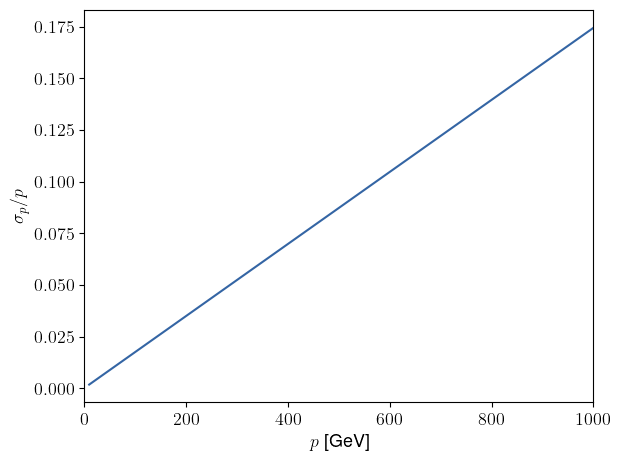

In [104]:
p = np.linspace(0, 1e3, 100)
sigma_p = get_sigma_p(p)

fig, ax = plt.subplots()
ax.plot(p, sigma_p / p)
ax.set_xlabel(r"$p$ [GeV]")
ax.set_ylabel(r"$\sigma_p/p$")
ax.set_xlim(p[0], p[-1])
plt.tight_layout()
plt.show()

In [114]:
root_path = get_root_path() / "10001/10001_000.root"
root_file = uproot.open(root_path)

faser_pos_columns = ["event_id", "trackerID", "energy", "x", "y", "z"]
faser_pos_df = ak.to_dataframe(
    root_file["Hits/faserHits"].arrays(faser_pos_columns, library="ak"),
    how="outer",
)
faser_pos_df.sort_values(
    ["event_id", "trackerID", "energy"], ascending=[True, True, False], inplace=True
)

# Number of hits per layer
faser_nhits_df = (
    faser_pos_df.query("energy > 10e3").groupby(["event_id", "trackerID"]).size()
)
faser_nhits_df = pd.DataFrame(faser_nhits_df, columns=["hit_counts"]).reset_index()
faser_nhits_event_df = faser_nhits_df.pivot(
    index="event_id", columns="trackerID", values=["hit_counts"]
)
faser_nhits_event_df.columns = [
    f"{col}_{int(tracker)}" for col, tracker in faser_nhits_event_df.columns
]

# Take hit with highest energy in each layer per event
faser_pos_df = faser_pos_df[
    ~faser_pos_df.duplicated(subset=["event_id", "trackerID"], keep="first")
]
faser_pos_df = faser_pos_df.fillna({"trackerID": 0})
# Create dataframe with one row per event and columns for each tracker layer's position
faser_pos_event_df = (
    faser_pos_df.query("~trackerID.isna()")
    .reset_index()
    .pivot(
        index="event_id",
        columns="trackerID",
        values=["x", "y", "z", "energy"],
    )
)
faser_pos_event_df.columns = [
    f"{col}_{int(tracker)}" for col, tracker in faser_pos_event_df.columns
]
faser_pos_event_df = faser_pos_event_df.reset_index()

faser_df = pd.merge(
    faser_pos_event_df,
    faser_nhits_event_df.reset_index(),
    on="event_id",
    how="left",
)
faser_df.fillna(0, inplace=True)

faser_df["p"] = faser_df["energy_0"] * 1e-3
faser_df["sigma_p"] = get_sigma_p(faser_df["p"]).values
faser_df["p_smear"] = (
    faser_df["p"] + np.random.randn(len(faser_df)) * faser_df["sigma_p"]
)

faser_df = faser_df[
    [i for i in faser_df.columns if i not in ["energy_0", "energy_1", "energy_2"]]
]

# faser_df = extrapolate_hits(faser_df, z0=1500)
# faser_df.rename(
#     {
#         "hit_counts_0": "nhits_0",
#         "hit_counts_1": "nhits_1",
#         "hit_counts_2": "nhits_2",
#     },
#     axis=1,
#     inplace=True,
# )
display(faser_df.head(10))

,event_id,x_0,x_1,x_2,y_0,y_1,y_2,z_0,z_1,z_2,hit_counts_0,hit_counts_1,hit_counts_2,p,sigma_p,p_smear
0,0,28.732004,28.617435,28.502840,49.631916,49.880665,50.057697,3159.39502,4349.39502,5539.39502,1.0,1.0,1.0,2832.779785,1400.235229,1591.055010
1,1,-6.775254,6.459557,19.694847,20.518251,21.819649,23.745543,3159.39502,4349.39502,5539.39502,1.0,1.0,1.0,322.816345,18.183872,324.723412
2,2,-60.063248,-62.013065,-63.961720,-64.834679,-86.147484,-107.532257,3159.39502,4349.39502,5539.39502,1.0,1.0,1.0,748.910828,97.866852,532.694669
3,3,70.603020,97.201881,123.800354,34.917130,36.965595,39.224072,3159.39502,4349.39502,5539.39502,1.0,1.0,1.0,407.508514,28.976686,394.347697
4,4,-114.371689,0.000000,0.000000,11.803488,0.000000,0.000000,3159.39502,0.00000,0.00000,1.0,0.0,0.0,242.806320,10.287156,244.020088
5,5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000
6,6,-107.373322,0.000000,0.000000,-60.417641,0.000000,0.000000,3159.39502,0.00000,0.00000,1.0,0.0,0.0,582.643250,59.235325,488.075755
7,7,-104.361755,-121.862106,0.000000,-14.357767,-59.914101,0.000000,3159.39502,4349.39502,0.00000,1.0,0.0,0.0,732.315674,93.577621,722.058729
8,8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000
9,9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [7]:
run = 10002
chunks = 0
label = get_label_from_run(run)
run_str = get_str_from_run(run)
num_events = 10
apply_truth_cuts = False
use_faser = True
use_truth_features = True

hits_df, truth_df, faser_df, tau_df = get_data(run=run, chunks=chunks)
# tau_df = tau_df.query("abs(PDG) == 16")[["evtID", "Px", "Py", "Pz"]].rename(
#     columns={"evtID": "event_id", "Px": "px_miss", "Py": "py_miss", "Pz": "pz_miss"}
# )

In [ ]:
truth_mu_df["p_miss"] = np.sqrt(
    truth_mu_df["px_miss"] ** 2
    + truth_mu_df["py_miss"] ** 2
    + truth_mu_df["pz_miss"] ** 2
)
truth_mu_df["E_vis"] = truth_mu_df["E_nu"] - truth_mu_df["p_miss"]
truth_mu_df["pt_miss"] = np.sqrt(
    truth_mu_df["px_miss"] ** 2 + truth_mu_df["py_miss"] ** 2
)
truth_mu_df["p_l"] = np.sqrt(
    truth_mu_df["px_mu"] ** 2 + truth_mu_df["py_mu"] ** 2 + truth_mu_df["pz_mu"] ** 2
)
truth_mu_df["pT_l"] = np.sqrt(truth_mu_df["px_mu"] ** 2 + truth_mu_df["py_mu"] ** 2)
truth_mu_df["p_jet"] = truth_mu_df["E_nu"] - truth_mu_df["p_miss"] - truth_mu_df["p_l"]
truth_mu_df["pT_jet"] = np.sqrt(
    (truth_mu_df["px_nu"] - truth_mu_df["px_miss"] - truth_mu_df["px_l"]) ** 2
    + (truth_mu_df["py_nu"] - truth_mu_df["py_miss"] - truth_mu_df["py_l"]) ** 2
)

In [53]:
truth_mu_df

,event_id,pdg_nu,vx,vy,vz,E_nu,px_nu,py_nu,pz_nu,charm,...,E_lepton,px_lepton,py_lepton,pz_lepton,px_miss,py_miss,pz_miss,px_mu,py_mu,pz_mu
0,6,-16,-3.750007,5.371742,43.600502,837.96,-0.006469,0.009280,837.960000,0,...,770.460876,1.544708,-4.560472,770.443726,0.231099,-1.100368,149.931018,1.305831,-3.459633,620.502632
1,8,-16,37.136704,57.981633,44.535616,1759.00,0.134602,0.210095,1758.999982,1,...,218.323761,2.558628,-2.810617,218.283447,2.464083,-2.575456,208.474534,0.092070,-0.253202,9.800629
2,12,16,117.247650,66.058995,43.306056,228.59,0.055195,0.031086,228.589991,0,...,193.295685,-0.532168,-1.854581,193.277878,-0.167498,-1.404995,123.723966,-0.351326,-0.470490,69.550309
3,17,-16,-100.526174,92.621880,42.185813,1113.10,-0.230000,0.211912,1113.099956,0,...,1102.290649,1.933519,-0.298616,1102.287598,0.606047,0.304891,594.704098,1.314428,-0.645312,507.502172
4,18,-16,51.834440,60.439180,41.780423,554.04,0.059166,0.068934,554.039993,0,...,152.209641,2.055807,-6.344906,152.053070,1.591693,-3.957924,103.636499,0.474786,-2.337143,48.326249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,478,-16,-117.996260,-47.967399,42.202903,1073.00,-0.260557,-0.105883,1072.999963,0,...,339.256805,6.388693,-2.591005,339.182068,2.792669,-1.080349,171.044597,3.597655,-1.501257,168.134271
93,479,16,-29.247029,-4.250065,41.007423,747.93,-0.045022,-0.006495,747.929999,0,...,252.206268,0.751981,-6.251487,252.121384,0.874292,-3.703163,161.562627,-0.129184,-2.566082,90.541549
94,482,16,-132.285673,-71.916241,41.252015,1046.90,-0.284767,-0.154784,1046.899950,0,...,914.607178,5.247914,-0.154989,914.590332,4.905706,-0.083533,887.342508,0.366102,-0.114449,27.114087
95,494,-16,106.164181,7.590796,44.020552,370.97,0.081046,0.005821,370.969991,0,...,159.083771,-1.457186,-9.216972,158.799911,-0.751961,-2.525460,48.248234,-0.715333,-6.696219,110.549505


In [ ]:
tau_mu_df.query()

,evtID,PID,TID,PDG,ParentPDG,ProdX,ProdY,ProdZ,DecayX,DecayY,DecayZ,Px,Py,Pz,is_had,is_mu,is_e
entry,,,,,,,,,,,,,,,,,
20,6,1,60021,-16,-15,-3.733046,5.321649,52.075217,12.569216,-103.400972,8447.280000,0.126905,-0.846351,65.352455,False,True,False
21,6,1,60020,-13,-15,-3.733046,5.321649,52.075217,15.846270,-40.034541,8447.280000,1.305831,-3.459633,620.502632,False,True,False
22,6,1,60019,14,-15,-3.733046,5.321649,52.075217,6.609133,-19.891856,8447.280000,0.104194,-0.254017,84.578563,False,True,False
23,6,1,60018,11,-15,-3.732568,5.207217,44.559503,-3.765354,5.259000,44.878128,-0.001214,0.001173,0.002851,False,True,False
27,8,1,1426565,-16,-15,37.233696,57.874644,52.822163,168.720287,-14.510018,8447.280000,2.152480,-1.184962,137.420126,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,494,1,212356,-13,-15,106.127109,7.357436,48.039539,84.674488,-258.000000,4441.623420,-0.715333,-6.696219,110.549505,False,True,False
2018,494,1,212355,14,-15,106.127109,7.357436,48.039539,10.644414,-258.000000,5069.103575,-0.882713,-2.453163,46.418474,False,True,False
2032,499,1,1127668,16,15,99.642783,-53.695501,41.734803,258.000000,107.272825,5009.512675,5.163432,5.248571,161.980515,False,True,False
